# Revisiting the use of dihedrals especially on the new area of interest 85:115 

In [2]:
from functions.CIF_Functions import make_df_atomlist
from functions.dihedrals import read_df,assign_dihedrals
import matplotlib.pyplot as plt
from numpy import array
 
atomlist =["CA","C","N"]

In [3]:
#df = make_df_atomlist("cif_files/Crystals/7stz (1).cif",atomlist)
#df = df[85*len(atomlist):115*len(atomlist)]
#df["auth_seq_id"] = [i for i in range(1, 31) for _ in range(3)]
#coords,seq = read_df(df)
#phi_list,psi_list = assign_dihedrals(coords)

df1 = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed42_ptms/fold_adnan_seed42_ptms_model_3.cif",atomlist)
df1 = df1[85*len(atomlist):115*len(atomlist)]
df1["auth_seq_id"] = [i for i in range(1, 31) for _ in range(3)]
coords1,seq1 = read_df(df1)
phi_list1,psi_list1 = assign_dihedrals(coords1)

df2 = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed1_noptms/fold_adnan_seed1_noptms_model_1.cif",atomlist)
df2 = df2[85*len(atomlist):115*len(atomlist)]
df2["auth_seq_id"] = [i for i in range(1, 31) for _ in range(3)]
coords2,seq2 = read_df(df2)
phi_list2,psi_list2 = assign_dihedrals(coords2)

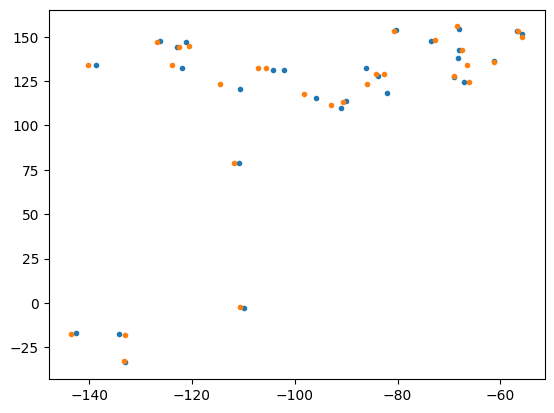

In [4]:
#plt.scatter(phi_list,psi_list,marker=".",label="Crystal")
plt.scatter(phi_list1,psi_list1,marker=".",label="PTM")
plt.scatter(phi_list2,psi_list2,marker=".",label="noPTM")


0.5754534623811458

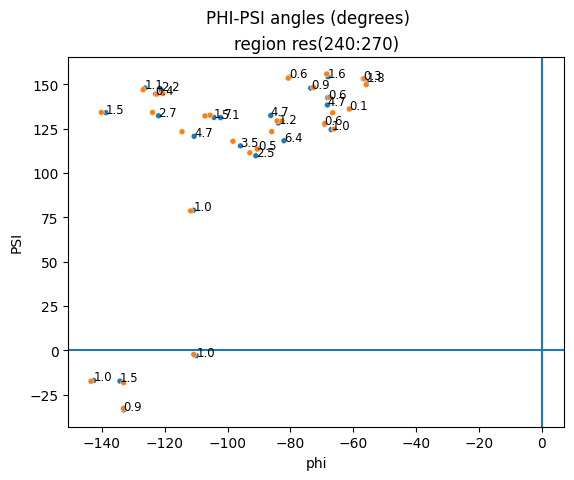

In [5]:
import math
import pandas as pd 
import seaborn as sns
import numpy as np

def distance(coord1, coord2) -> float:
    x1, y1 = coord1
    x2, y2 = coord2
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

distancelist = []
for i in range(len(phi_list1)):
    dist = distance((phi_list1[i],psi_list1[i]),(phi_list2[i],psi_list2[i]))
    if dist > 180:
        dist = 360-dist
    distancelist.append(round(dist,1))


df_plt= pd.DataFrame({"phi":phi_list1,
                  "psi":psi_list1,
                  "residues":distancelist})

p1 = sns.scatterplot(x='phi', # Horizontal axis
       y='psi', # Vertical axis
       data=df_plt, # Data source
       size = 8,
       legend=False)  

for line in range(0,df_plt.shape[0]):
     p1.text(df_plt.phi[line]+0.01, df_plt.psi[line], 
     df_plt.residues[line], horizontalalignment='left', 
     size='small', color='black')

sns.scatterplot(x=phi_list2,y=psi_list2,size=8,legend=False)  
plt.suptitle("PHI-PSI angles (degrees)")
plt.title(f'region res({85+155}:{115+155})')
# Set x-axis label
plt.xlabel('phi')
# Set y-axis label
plt.ylabel('PSI')
plt.axhline(0)
plt.axvline(0)  

np.average(array(phi_list1)- array(phi_list2))

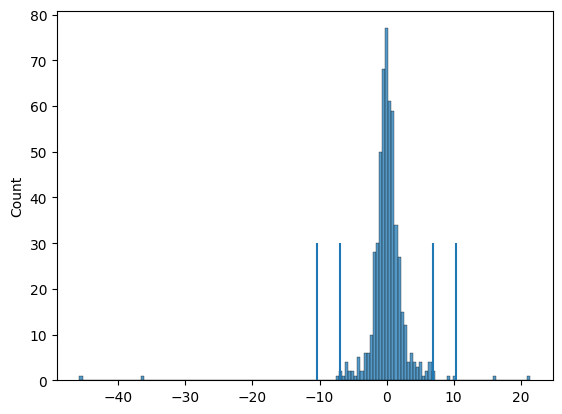

In [6]:
import numpy as np
import seaborn as sns
df1 = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed42_ptms/fold_adnan_seed42_ptms_model_3.cif",atomlist)
coords1,seq1 = read_df(df1)
phi_list1,psi_list1 = assign_dihedrals(coords1)

df2 = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed1_noptms/fold_adnan_seed1_noptms_model_1.cif",atomlist)
coords2,seq2 = read_df(df2)
phi_list2,psi_list2 = assign_dihedrals(coords2)


sns.histplot(array(phi_list1)- array(phi_list2))

sig2 = 2*np.std(array(phi_list1)- array(phi_list2))
sig3 = 3*np.std(array(phi_list1)- array(phi_list2))

plt.vlines([sig2,sig3,-sig2,-sig3],ymax=30,ymin=0)


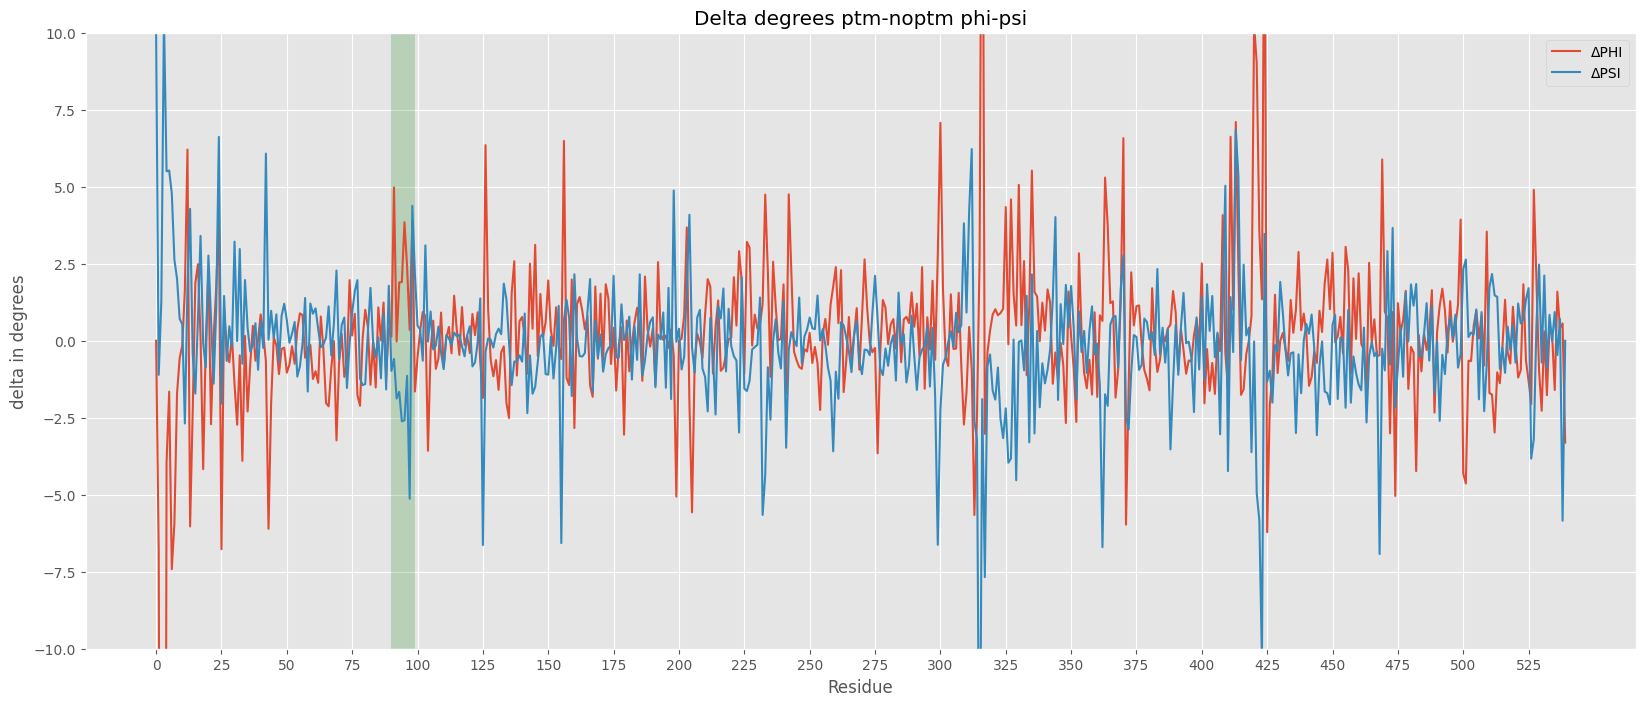

In [12]:
deltaphi = np.append(0,(array(phi_list1) - array(phi_list2)))
deltapsi = np.append(array(psi_list1) - array(psi_list2),0)
plt.style.use(style="ggplot")
from matplotlib.patches import Rectangle
plt.figure(figsize=(20,8))
# for i,j in [(0,5),(99,14),(212,14),(324,13),(431,13),(532,8)]:
#     plt.gca().add_patch(Rectangle((i,-20),j,40,linewidth=1,edgecolor='none',facecolor='grey',alpha=.3))
# plt.vlines(array([126, 204,206, 314, 316, 318,422,424,426]),-20,20,alpha=.5,colors="red",label="Manose binding residues",linewidth=.8)
#plt.suptitle("Delta degrees ptm-noptm phi-psi")
plt.title("Delta degrees ptm-noptm phi-psi")
plt.xlabel("Residue")
plt.ylabel("delta in degrees")


plt.plot(deltaphi,label = '\u0394PHI')
plt.plot(deltapsi,label='\u0394PSI')


plt.ylim(-10,10)
plt.xticks(np.arange(0,540,25));
plt.gca().add_patch(Rectangle((90,-20),9,40,linewidth=1,edgecolor='none',facecolor='green',alpha=.2))
plt.legend()
plt.savefig("fig6.png",bbox_inches="tight")
plt.show()
#plt.plot(range(85,115),deltaphi[85:115])
#plt.plot(range(85,115),deltapsi[85:115]);

([<matplotlib.axis.XTick at 0x19a2bbe38d0>,
 [Text(0, 0, '0'),
  Text(25, 0, '25'),
  Text(50, 0, '50'),
  Text(75, 0, '75'),
  Text(100, 0, '100'),
  Text(125, 0, '125'),
  Text(150, 0, '150'),
  Text(175, 0, '175'),
  Text(200, 0, '200'),
  Text(225, 0, '225'),
  Text(250, 0, '250'),
  Text(275, 0, '275'),
  Text(300, 0, '300'),
  Text(325, 0, '325'),
  Text(350, 0, '350'),
  Text(375, 0, '375'),
  Text(400, 0, '400'),
  Text(425, 0, '425'),
  Text(450, 0, '450'),
  Text(475, 0, '475'),
  Text(500, 0, '500'),
  Text(525, 0, '525')])

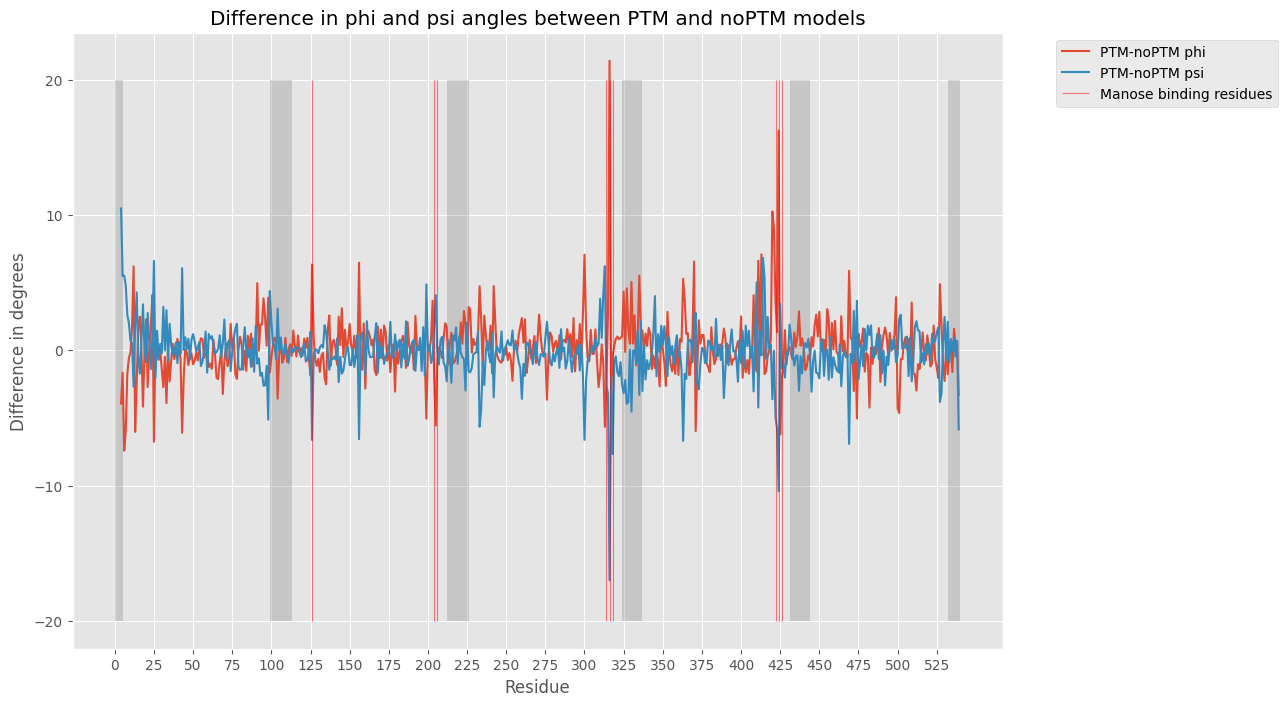

In [8]:
from matplotlib.patches import Rectangle
plt.figure(figsize=(12,8))
plt.plot(array(range(4,540)),(array(phi_list1)- array(phi_list2))[3:],label="PTM-noPTM phi")
plt.plot(array(range(4,540)),(array(psi_list1)- array(psi_list2))[3:],label="PTM-noPTM psi")

plt.vlines(array([126, 204,206, 314, 316, 318,422,424,426]),-20,20,alpha=.5,colors="red",label="Manose binding residues",linewidth=.8)

#plt.vlines(array([85, 95,300, 316, 324,400,422]),-20,20,alpha=.5,colors="green",label="regions of interest",linewidth=1)
#for i,j in [(85,10),(300,24),(400,22)]:
#    plt.gca().add_patch(Rectangle((i,-20),j,40,linewidth=1,edgecolor='none',facecolor='green',alpha=.3))

for i,j in [(0,5),(99,14),(212,14),(324,13),(431,13),(532,8)]:
    plt.gca().add_patch(Rectangle((i,-20),j,40,linewidth=1,edgecolor='none',facecolor='grey',alpha=.3))

plt.title("Difference in phi and psi angles between PTM and noPTM models")
plt.xlabel("Residue")
plt.ylabel("Difference in degrees")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(np.arange(0,539,25))
# plt slack for Anton

2.32456484386494

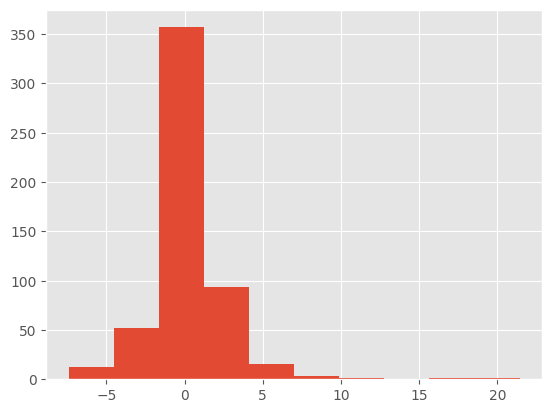

In [9]:
plt.hist((array(phi_list1)- array(phi_list2))[3:])
np.std((array(phi_list1)- array(phi_list2))[3:])

Text(0, 0.5, 'Difference in angle residue')

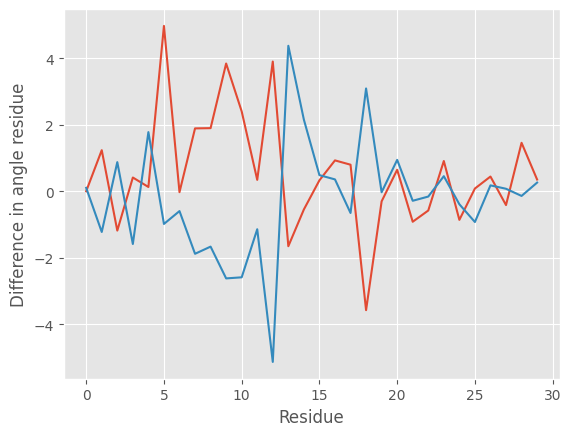

In [10]:
plt.plot((array(phi_list1)- array(phi_list2))[85:115])
plt.plot((array(psi_list1)- array(psi_list2))[85:115])
plt.xlabel("Residue")
plt.ylabel("Difference in angle residue")

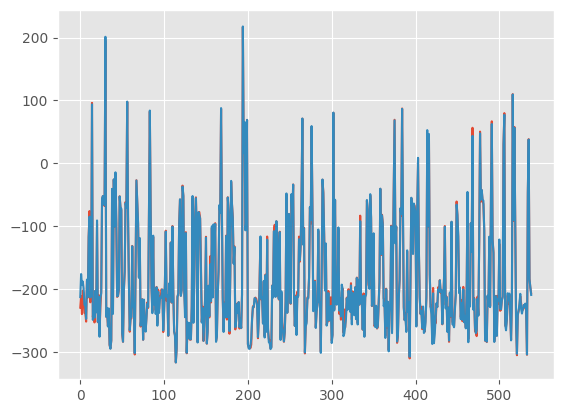

In [11]:
plt.plot(array(phi_list1)- array(psi_list1))
plt.plot(array(phi_list2)- array(psi_list2))